In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings

In [50]:
warnings.filterwarnings("ignore")
f_inbound = pd.read_excel(r'C:\Users\rajeshkumar.t\Desktop\BBD\CTU_Offered.xlsx',index_col=0)
f_inbound = f_inbound[["Date","PL Email"]]
f_inbound.head()
print(f_inbound.columns)

Index(['Date', 'PL Email'], dtype='object')


In [45]:
type(f_inbound)

pandas.core.frame.DataFrame

In [27]:
series_values= f_inbound.values
type(series_values)

numpy.ndarray

In [28]:
f_inbound.size

4845

In [67]:
f_inbound.tail()

,PL Email
Date,
2024-11-14,385
2024-11-15,386
2024-11-16,391
2024-11-17,336
2024-11-18,444


In [68]:
f_inbound.describe()

,PL Email
count,323.000000
mean,472.910217
std,156.452009
min,210.000000
25%,393.000000
50%,453.000000
75%,506.000000
max,1554.000000


<Axes: xlabel='Date'>

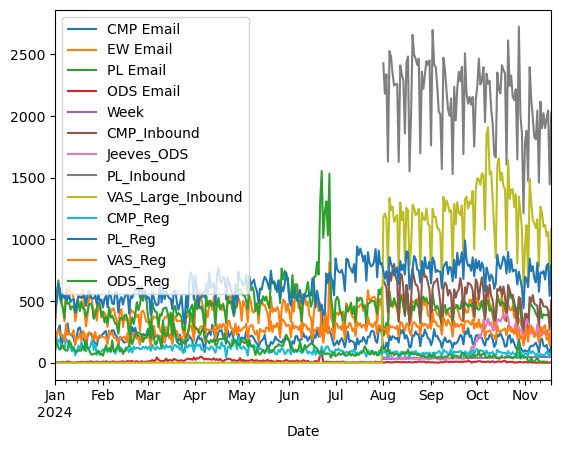

In [21]:
f_inbound.plot()

In [80]:
f_inbound_mean = f_inbound.rolling(window = 20).mean()

NameError: name 'f_inbound_mean' is not defined

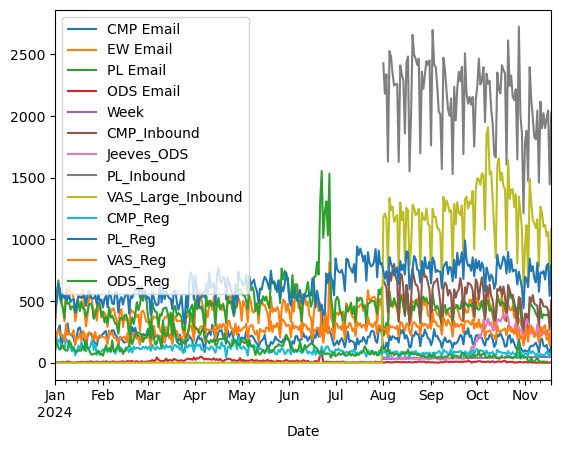

In [20]:
f_inbound.plot()
f_inbound_mean.plot()

In [89]:
value = pd.DataFrame(series_values)

In [119]:
f_inbound_df = pd.concat([value, value.shift(1)],axis=1)

In [120]:
f_inbound_df.head()

,0,0
0,363,NaN
1,539,363.0
2,667,539.0
3,528,667.0
4,479,528.0


In [121]:
f_inbound_df.columns = ['Autual_inflow', 'Forecast_inflow']

In [122]:
f_inbound_df.head()

,Autual_inflow,Forecast_inflow
0,363,NaN
1,539,363.0
2,667,539.0
3,528,667.0
4,479,528.0


In [123]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [124]:
f_inbound_test = f_inbound_df[1:]


In [125]:
f_inbound_test.head()

,Autual_inflow,Forecast_inflow
1,539,363.0
2,667,539.0
3,528,667.0
4,479,528.0
5,438,479.0


In [126]:
f_inbound_error = mean_squared_error(f_inbound_test.Autual_inflow,f_inbound_test.Forecast_inflow)

In [127]:
f_inbound_error

14337.10248447205

In [128]:
np.sqrt(f_inbound_error)

119.7376402158989

In [ ]:
ARIMA - Autoregression (p) integrated(d) moving average(q)

In [109]:
from statsmodels.graphics.tsaplots  import plot_acf, plot_pacf

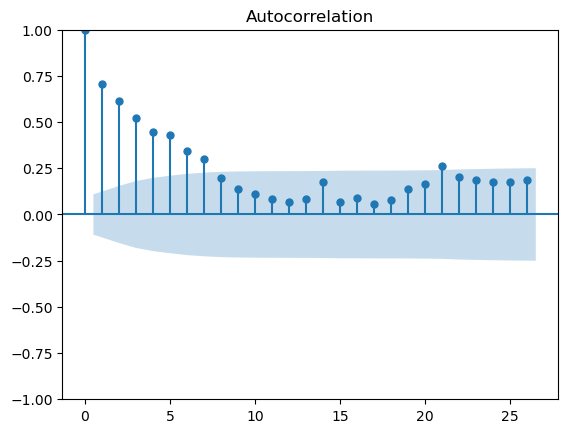

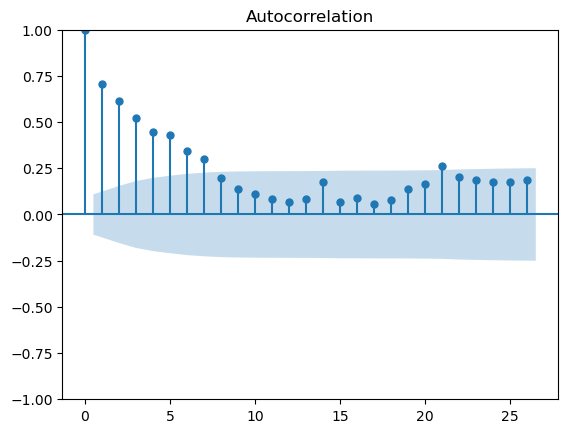

In [129]:
plot_acf(f_inbound)  # to idenfity the value of Q

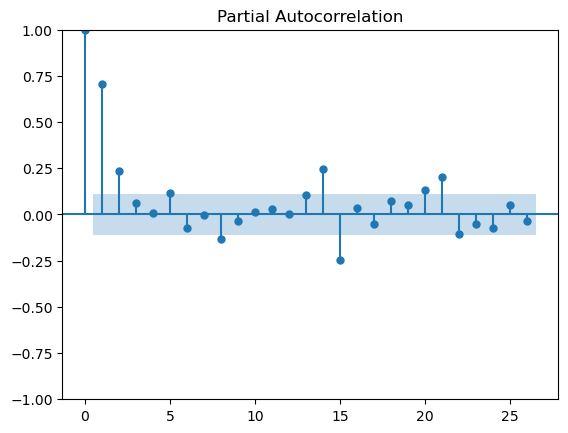

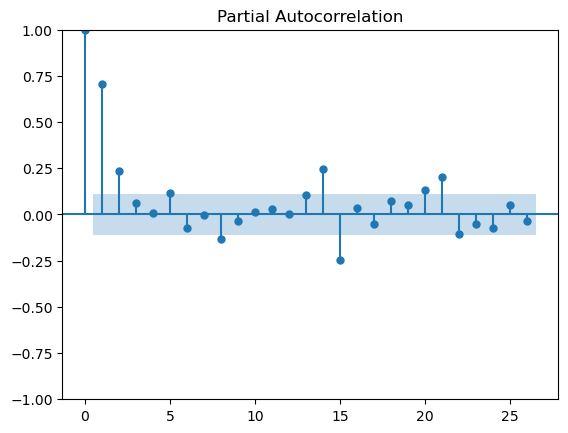

In [130]:
plot_pacf(f_inbound) # to identify the value of p

In [ ]:
# p=2, 3 Q 2-10 , d= 

In [132]:
f_inbound.size

323

In [135]:
f_inbound_train = f_inbound[0:300]
f_inbound_test = f_inbound[300:323]

In [136]:
f_inbound_train.size


300

In [140]:
from statsmodels.tsa.arima.model import ARIMA

In [189]:
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

# Initialize variables to store the best results
best_aic = float('inf')
best_model = None
best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Fit the ARIMA model with the given order (p, d, q)
                model = ARIMA(f_inbound_train, order=(p, d, q))
                model_fit = model.fit()
                
                # Get the AIC value for the current model
                aic = model_fit.aic
                print(f"Trying ARIMA({p}, {d}, {q}) - AIC: {aic}")
                
                # If the current model has a lower AIC, update the best model
                if aic < best_aic:
                    best_aic = aic
                    best_model = model_fit
                    best_order = (p, d, q)
            except Exception as e:
                # In case of any errors, print the error and continue
                print(f"Error with ARIMA({p}, {d}, {q}): {e}")
                continue

# Print the best model and its order after all combinations
print(f"Best ARIMA model: ARIMA{best_order} with AIC: {best_aic}")


C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_mo

Trying ARIMA(0, 0, 0) - AIC: 3898.4492467923847
Trying ARIMA(0, 0, 1) - AIC: 3781.492514130246
Trying ARIMA(0, 0, 2) - AIC: 3732.2935031227726
Trying ARIMA(0, 0, 3) - AIC: 3704.446212289354


C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_mo

Trying ARIMA(0, 1, 0) - AIC: 3723.068695066235
Trying ARIMA(0, 1, 1) - AIC: 3679.683346505819
Trying ARIMA(0, 1, 2) - AIC: 3680.6881804503655
Trying ARIMA(0, 1, 3) - AIC: 3680.1748486240836
Trying ARIMA(1, 0, 0) - AIC: 3692.1918712380293
Trying ARIMA(1, 0, 1) - AIC: 3677.4120880322234


C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_mo

...

C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Trying ARIMA(3, 1, 2) - AIC: 3670.32631935193


C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Trying ARIMA(3, 1, 3) - AIC: 3658.7386990536397
Best ARIMA model: ARIMA(3, 1, 3) with AIC: 3658.7386990536397


C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [193]:
f_inbound_model = ARIMA(f_inbound_train, order=(3,1,3))

C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajeshkumar.t\AppData\Local\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [196]:
f_inbound_model_fit = f_inbound_model.fit()

IndexError: index 6 is out of bounds for axis 0 with size 1

In [192]:
f_inbound_model_fit.aic

3666.906947511772

In [164]:
f_inbound_forecast= f_inbound_model_fit.forecast(steps=23)

In [161]:
f_inbound_forecast

2024-10-27    462.169490
2024-10-28    469.024592
2024-10-29    472.944256
2024-10-30    460.640580
2024-10-31    449.356306
2024-11-01    441.360464
2024-11-02    447.488311
2024-11-03    458.539145
2024-11-04    470.122916
2024-11-05    470.315929
2024-11-06    462.200794
2024-11-07    449.327216
2024-11-08    443.560986
2024-11-09    446.984059
2024-11-10    458.631267
2024-11-11    468.207146
2024-11-12    470.061614
2024-11-13    461.815633
2024-11-14    450.801069
2024-11-15    444.274210
2024-11-16    447.738464
2024-11-17    457.722078
2024-11-18    467.347610
2024-11-19    468.999941
2024-11-20    462.112223
2024-11-21    451.528328
2024-11-22    445.482983
2024-11-23    448.006153
2024-11-24    457.330540
2024-11-25    466.197959
2024-11-26    468.307288
2024-11-27    462.067359
2024-11-28    452.420766
2024-11-29    446.397648
2024-11-30    448.477660
Freq: D, Name: predicted_mean, dtype: float64

In [159]:
f_inbound_test

,PL Email
Date,
2024-10-27,359
2024-10-28,519
2024-10-29,423
2024-10-30,303
2024-10-31,261
2024-11-01,398
2024-11-02,375
2024-11-03,270
2024-11-04,479


In [165]:
np.sqrt(mean_squared_error(f_inbound_test, f_inbound_forecast))

88.9067096732921

In [178]:
print(f_inbound.columns)

Index(['PL Email'], dtype='object')
